# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("/workspaces/ds-fall-2026/Week-05-Business-Stats-Analytics/data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [27]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()

df.duplicated().sum()
df[df.duplicated()]
clean = df.drop_duplicates()
clean.shape

(11194, 15)

In [28]:
clean.isna().sum()
clean = clean.dropna()
clean.shape


(11092, 15)

In [29]:
clean['Transmission Type'].value_counts()
#clean[clean['Transmission Type'] == 'UNKNOWN']

clean = clean[clean['Transmission Type'] != 'UNKNOWN']
#sanity check
clean['Transmission Type'].value_counts()



Transmission Type
AUTOMATIC           7893
MANUAL              2620
AUTOMATED_MANUAL     552
DIRECT_DRIVE          15
Name: count, dtype: int64

In [30]:
clean['Engine Fuel Type'].value_counts()
clean['Engine HP'].value_counts()
clean['Engine Cylinders'].value_counts()

#clean[clean['Engine Cylinders'] == 0.0]
clean = clean[clean['Engine Cylinders'] != 0.0]
clean['Engine Cylinders'].value_counts()



Engine Cylinders
4.0     4348
6.0     4264
8.0     1961
12.0     227
5.0      169
10.0      65
3.0       30
16.0       3
Name: count, dtype: int64

In [31]:
clean['Driven_Wheels'].value_counts()
clean['Number of Doors'].value_counts()
clean['Vehicle Size'].value_counts()
clean['Vehicle Style'].value_counts()


Vehicle Style
Sedan                  2804
4dr SUV                2426
Coupe                  1152
Convertible             739
Crew Cab Pickup         654
4dr Hatchback           626
Extended Cab Pickup     597
Wagon                   557
2dr Hatchback           406
Passenger Minivan       384
Regular Cab Pickup      344
Passenger Van           121
2dr SUV                  87
Cargo Van                84
Cargo Minivan            58
Convertible SUV          28
Name: count, dtype: int64

In [32]:
clean.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11067.000000,11067.000000,11067.000000,11067.000000,11067.000000,11067.000000,11067.000000,1.106700e+04
mean,2010.702449,253.708141,5.694497,3.451161,26.186862,19.185778,1557.253908,4.195871e+04
std,7.233432,110.213797,1.756815,0.874274,6.998964,5.592962,1443.965993,6.179869e+04
min,1990.000000,55.000000,3.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.158500e+04
50%,2015.000000,240.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.061000e+04
75%,2016.000000,303.500000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.307500e+04
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,58.000000,5657.000000,2.065902e+06


In [37]:
# Outliers
clean.nlargest(10, 'highway MPG')

clean = clean[clean['highway MPG'] != 354]
#clean.nlargest(10, 'highway MPG')

In [38]:
clean.dtypes

Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | 720 duplicates|df.duplicated().sum() | 720| dropped them|to get rid of them|
| 2 | Nulls|.isna().sum()| 102|dropped them| 102 will not affect 11k+ rows of data|
| 3 | Unknown transmission|.value_counts() |12 | dropped them|12 will not affect the data |
| 4 | 0 Cylinder| cykinder.value_counts() |13 | dropped them |will not affect the data |
| 5 |354 |.nlargest() | 1 |removed it |this must be an error |

In [39]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
# clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [40]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11066, 15)
Series([], dtype: int64)


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean:  41957.84, Median:  30605.0
26.65 % of the cars coast more the mean


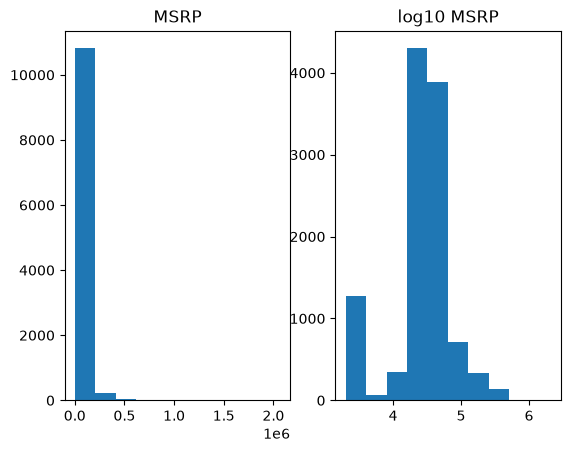

In [41]:
# a) mean and median
print(f'Mean:  {clean['msrp'].mean():.2f}, Median:  {clean['msrp'].median()}')



# b) two histograms side by side (plt.subplots(1, 2))
fig, ax = plt.subplots(1,2)

ax[0].hist(clean['msrp'])
ax[0].set_title('MSRP')

ax[1].hist(np.log10(clean['msrp']))
ax[1].set_title('log10 MSRP')

fig.show()



# c) share of cars above the mean
mean = clean['msrp'].mean()
n_cars_above_the_mean = (clean['msrp'] > mean).sum()
p_cars_above_the_mean = n_cars_above_the_mean / clean.shape[0] *100
print(f'{p_cars_above_the_mean:.2f} % of the cars coast more the mean')


### **Answer:**

A) The mean is significantly bigger because there are outliers <br>
B) The MSRP is strongly right skewed because a few cars are much more expensive than the others,<br>
    The log 10 is less skewed so it shows the range more clearly<br>
D) definitely the Median

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [42]:
cars_2017 = clean[clean['year'] == 2017]

# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars_2017.groupby('vehicle_size')['highway_mpg'].agg(['mean','std'])


,mean,std
vehicle_size,,
Compact,30.895050,6.066339
Large,22.956710,3.498724
Midsize,29.356467,5.426434


In [43]:
# b) z = (value - class mean) / class std
civic_z_score = (42 - 30.89) / 6.066
volvo_z_score = (34 - 22.95) / 3.498

print(f'civic Z-score: {civic_z_score:.2f} \nVolvo Z-score: {volvo_z_score:.2f}')

civic Z-score: 1.83 
Volvo Z-score: 3.16


### **Answer:**<br>
The Volvo is more efficient, it is 3.16 standard deviations above the average large car. the civic is 1.83 standard deviations above the compact car

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

Median: 36650.0


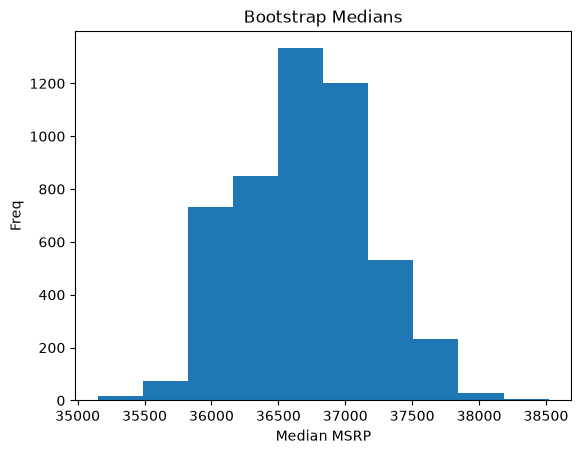

95% interval: 35870.00 to 37695.00


In [44]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""

    medians = []
    for i in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))

    return np.array(medians)


# a, b)
median = cars_2017['msrp'].median()
print(f'Median: {median}')


medians = bootstrap_median(cars_2017['msrp'])

plt.hist(medians)
plt.title('Bootstrap Medians')
plt.xlabel('Median MSRP')
plt.ylabel('Freq')
plt.show()


lower = np.percentile(medians, 2.5)
upper = np.percentile(medians, 97.5)

print(f'95% interval: {lower:.2f} to {upper:.2f}')



Median: 47615.0


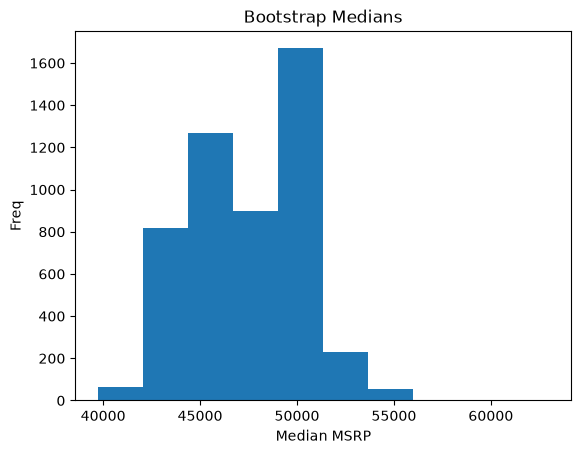

95% interval: 42770.00 to 53035.0


In [45]:

# c)
cars_2017['make'].value_counts()

lexus_2017 = cars_2017[cars_2017['make'] == 'Lexus']
lexus_2017.shape    # 34 cars


median = lexus_2017['msrp'].median()
print(f'Median: {median}')


medians = bootstrap_median(lexus_2017['msrp'])

plt.hist(medians)
plt.title('Bootstrap Medians')
plt.xlabel('Median MSRP')
plt.ylabel('Freq')
plt.show()


lower = np.percentile(medians, 2.5)
upper = np.percentile(medians, 97.5)

print(f'95% interval: {lower:.2f} to {upper}')


### **Answer:**

C) The Lexus interval is wider because it has a much smaller sample size<br>
D) We are 95% confident that the typical price of a 2017 car is between about $42,770 and $53,035.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

number of compact cars in 2017:  505,
Average highway MPG: 30.90


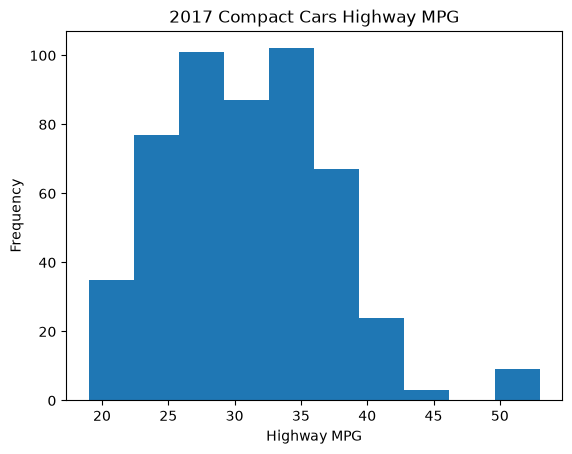

t-statistic: 3.3156 
p-value: 0.000490137300780739


In [46]:


# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = cars_2017[cars_2017['vehicle_size'] == 'Compact']
compact_2017['vehicle_size'].value_counts()
n = compact_2017.shape[0]
mean = compact_2017['highway_mpg'].mean()
print(f'number of compact cars in 2017:  {n},\nAverage highway MPG: {mean:.2f}')

plt.hist(compact_2017['highway_mpg'])
plt.xlabel('Highway MPG')
plt.ylabel('Frequency')
plt.title('2017 Compact Cars Highway MPG')
plt.show()

# yes the t-test is reasonable bec the n is pretty large


# c) one-sample t-test vs 30
result = stats.ttest_1samp(
    compact_2017['highway_mpg'],
    30, 
    alternative="greater"
)

print(f't-statistic: {result.statistic:.4f} \np-value: {result.pvalue}')


### **Answer:**<br><br>
A) H₀: The mean MPG of 2017 compact cars is 30 or less<br>
     Hₐ: The mean greater than 30<br><br>
C) Since the p-value is too small (smaller than 0.05), we can reject the null hypothesis. So the mean is greater than 30 MPG

In [47]:
# d) rows per make+model, then one row per model and retest

compact_2017.groupby(['make', 'model']).size()

compact_2017_one_make_model = compact_2017.groupby(['make', 'model'])['highway_mpg'].mean()

compact_2017_one_make_model



result = stats.ttest_1samp(
    compact_2017_one_make_model,
    30, 
    alternative="greater"
)

print(f't-statistic: {result.statistic:.4f} \np-value: {result.pvalue}')


t-statistic: 2.5773 
p-value: 0.005851341042610617


### **Answer**<br>
the P value incresed but it is still below 0.05 so we still reject the null hypothesis

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [48]:
clean['transmission_type'].value_counts()

auto_manual_transmission  = clean[(clean['transmission_type'] == 'AUTOMATIC') | (clean['transmission_type'] == 'MANUAL')]
auto_manual_transmission['transmission_type'].value_counts()


# a) compare median MSRP by transmission type
print(f'MEDIAN MSRP BY TRANSMISSION TYPE:\n {auto_manual_transmission.groupby('transmission_type')['msrp'].median()}')



# b) compare year by transmission type
auto_manual_transmission_by_year = auto_manual_transmission.groupby(['year','transmission_type']).size().unstack()
auto_manual_transmission_by_year
# Manual cars are more common in the old years so that might affect the price





# c) compare 2015-2017 medians overall and within each vehicle_size

auto_manual_2015_2017_cars  = auto_manual_transmission[(auto_manual_transmission['year'] >= 2015)]
auto_manual_2015_2017_cars['year'].value_counts()

print(f'\nMEDIAN MSRP BY TRANSMISSION TYPE From 2015-2017:\n {auto_manual_2015_2017_cars.groupby('transmission_type')['msrp'].median()}')

#within each vehivle size
print(f'\nMEDIAN MSRP BY TRANSMISSION TYPE, SIZE From 2015-2017:\n {auto_manual_2015_2017_cars.groupby(['vehicle_size','transmission_type'])['msrp'].median().unstack()}')



# For 2015-17 compacts, test automatic vs manual prices with:
compacts_15_17 = auto_manual_2015_2017_cars[auto_manual_2015_2017_cars['vehicle_size']== 'Compact']

auto = compacts_15_17[compacts_15_17['transmission_type'] == 'AUTOMATIC']['msrp']
manual = compacts_15_17[compacts_15_17['transmission_type'] == 'MANUAL']['msrp']


result = stats.mannwhitneyu(auto,manual)

print(f'\np-value: {result.pvalue}')

# p - 0.199 which is >0.05, so there is no significant difference in price

MEDIAN MSRP BY TRANSMISSION TYPE:
 transmission_type
AUTOMATIC    33025.0
MANUAL       19342.5
Name: msrp, dtype: float64

MEDIAN MSRP BY TRANSMISSION TYPE From 2015-2017:
 transmission_type
AUTOMATIC    37037.5
MANUAL       26905.0
Name: msrp, dtype: float64

MEDIAN MSRP BY TRANSMISSION TYPE, SIZE From 2015-2017:
 transmission_type  AUTOMATIC   MANUAL
vehicle_size                         
Compact              25995.0  25860.0
Large                44410.0  38395.0
Midsize              37962.5  26920.0

p-value: 0.1990381369881946


### **Answer:**<br>
There is no significant differnece in price between recent compacts manuals vs automatics

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [54]:

# a) Welch t-test, 4-door vs 2-door
clean['number_of_doors'].value_counts()

four_door_cars = clean[clean['number_of_doors'] == 4.0]['highway_mpg']
two_door_cars = clean[clean['number_of_doors'] == 2.0]['highway_mpg']

result = stats.ttest_ind(four_door_cars, two_door_cars, equal_var=False)

print(f'Average MPG for 4-door cars: {four_door_cars.mean():.2f}')
print(f'Average MPG for 2-door cars: {two_door_cars.mean():.2f}')
print(f'Difference in means: {four_door_cars.mean() - two_door_cars.mean():.2f}')
print(f'p-value: {result.pvalue}')



# b) yearly gas cost = miles * price_per_gallon / mpg
four_door_cost = 12000 * 3.50 / four_door_cars.mean()
two_door_cost = 12000 * 3.50 / two_door_cars.mean()

print(f'\n\n4-door yearly cost: ${four_door_cost:.2f}')
print(f'2-door yearly cost: ${two_door_cost:.2f}')
print(f'4-door yearly savings ${two_door_cost - four_door_cost:.2f}')


# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):

    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    four_door_sample = rng.choice(four_door_cars, 30, replace=False)
    two_door_sample = rng.choice(two_door_cars, 30, replace=False)

    result = stats.ttest_ind(four_door_sample, two_door_sample, equal_var=False)

    if result.pvalue <0.05:
        hits +=1


print(f'\n\nsignificant Fraction: {hits / n_sims}')



Average MPG for 4-door cars: 26.81
Average MPG for 2-door cars: 25.27
Difference in means: 1.54
p-value: 6.416615154104986e-32


4-door yearly cost: $1566.39
2-door yearly cost: $1661.93
4-door yearly savings $95.54


significant Fraction: 0.155


### **Answer:**<br>
I wouldn't say that 4-door cars are more fuel-efficient bec the difference is small. I would say that 4-door cars average about 1.54 MPG more and save about $95.54 per year on gas

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

### **Memo:**

- Manual cars cost less overall (Avg price: $19,342.50) compared to $33,025 for automatic cars. However, for recent compact cars, the avg prices were much closer. so transmission type alone does not explain the price difference. 
- An important finding: car prices are highly skewed because there is a small number of very expensive cars raise the average
- One limitation is that the dataset contains cars from different years and models so we must be careful comparing groups

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2